In [3]:
!pip install -q ucimlrepo


In [4]:
from ucimlrepo import fetch_ucirepo

# Fetch Student Performance dataset
student_performance = fetch_ucirepo(id=320)

# Separate features and target
X = student_performance.data.features
y = student_performance.data.targets

print("Dataset loaded successfully!")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset loaded successfully!
Features shape: (649, 30)
Target shape: (649, 3)


In [5]:
print("Feature columns:")
print(X.columns.tolist())

print("\nTarget columns:")
print(y.columns.tolist())

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Target columns:
['G1', 'G2', 'G3']


In [6]:
# Display the first 10 student records
X.head(10)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0
5,GP,M,16,U,LE3,T,4,3,services,other,...,yes,yes,no,5,4,2,1,2,5,6
6,GP,M,16,U,LE3,T,2,2,other,other,...,yes,yes,no,4,4,4,1,1,3,0
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,yes,no,no,4,1,4,1,1,1,2
8,GP,M,15,U,LE3,A,3,2,services,other,...,yes,yes,no,4,2,2,1,1,1,0
9,GP,M,15,U,GT3,T,3,4,other,other,...,yes,yes,no,5,5,1,1,1,5,0


In [7]:
# Check for duplicate records

duplicate_count = X.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [8]:
# Check the data types of all features

print("Data types of each feature:")
print(X.dtypes)

Data types of each feature:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
dtype: object


In [9]:
# Check the target grade columns

print("First 10 target records:")
print(y.head(10))

print("\nTarget data types:")
print(y.dtypes)

print("\nFinal grade (G3) statistics:")
print(y["G3"].describe())

First 10 target records:
   G1  G2  G3
0   0  11  11
1   9  11  11
2  12  13  12
3  14  14  14
4  11  13  13
5  12  12  13
6  13  12  13
7  10  13  13
8  15  16  17
9  12  12  13

Target data types:
G1    int64
G2    int64
G3    int64
dtype: object

Final grade (G3) statistics:
count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


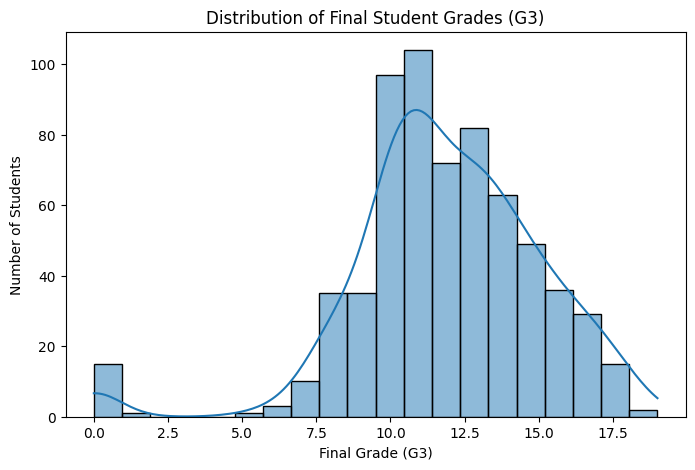

In [11]:
# Visualize the distribution of final grades (G3)

plt.figure(figsize=(8, 5))

sns.histplot(y["G3"], bins=20, kde=True)

plt.title("Distribution of Final Student Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

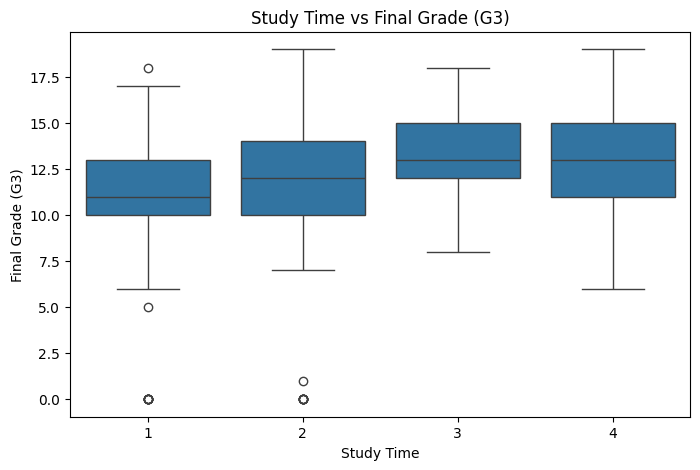

In [12]:
# Study time vs Final Grade

plt.figure(figsize=(8, 5))

sns.boxplot(x=X["studytime"], y=y["G3"])

plt.title("Study Time vs Final Grade (G3)")
plt.xlabel("Study Time")
plt.ylabel("Final Grade (G3)")

plt.show()

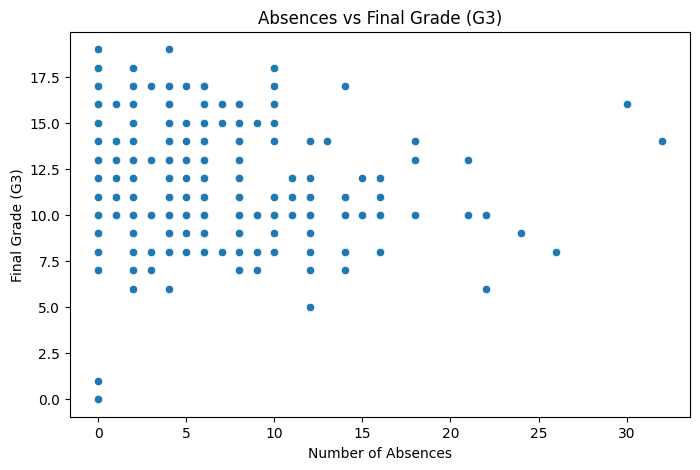

In [13]:
# Absences vs Final Grade

plt.figure(figsize=(8, 5))

sns.scatterplot(x=X["absences"], y=y["G3"])

plt.title("Absences vs Final Grade (G3)")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade (G3)")

plt.show()

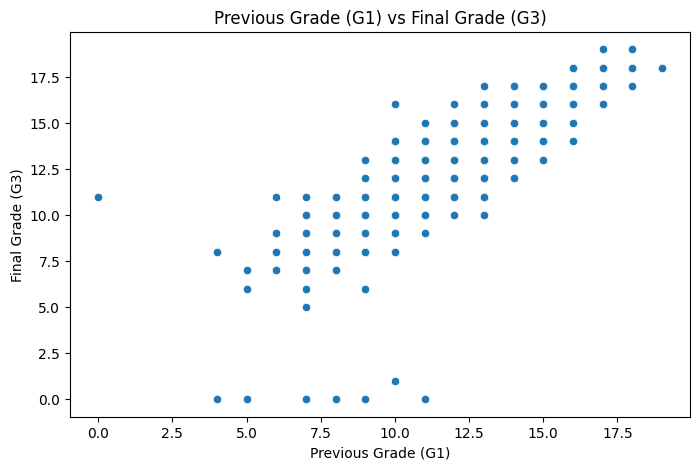

In [14]:
# Previous Grade (G1) vs Final Grade (G3)

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y["G1"], y=y["G3"])

plt.title("Previous Grade (G1) vs Final Grade (G3)")
plt.xlabel("Previous Grade (G1)")
plt.ylabel("Final Grade (G3)")

plt.show()

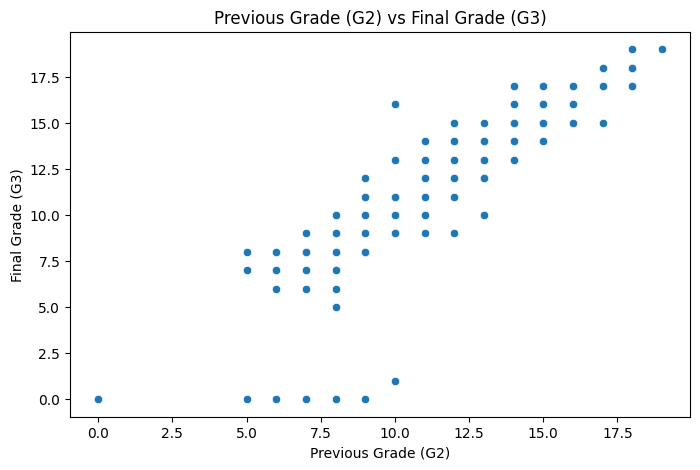

In [15]:
# Previous Grade (G2) vs Final Grade (G3)

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y["G2"], y=y["G3"])

plt.title("Previous Grade (G2) vs Final Grade (G3)")
plt.xlabel("Previous Grade (G2)")
plt.ylabel("Final Grade (G3)")

plt.show()

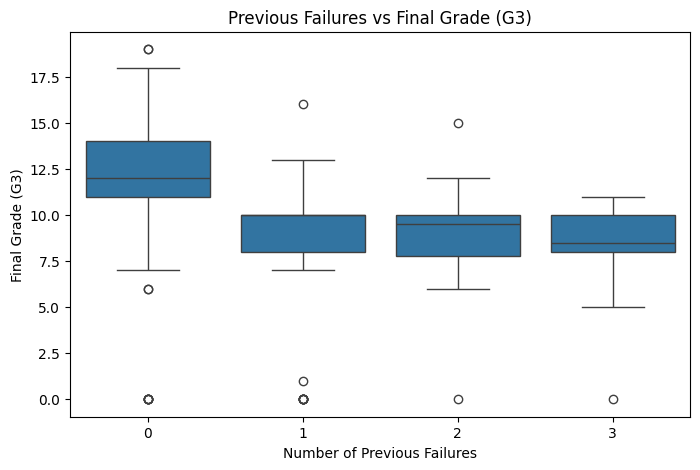

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=X["failures"], y=y["G3"])

plt.title("Previous Failures vs Final Grade (G3)")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")

plt.show()

In [17]:
# Combine features and target grades

model_data = X.copy()

model_data["G1"] = y["G1"]
model_data["G2"] = y["G2"]
model_data["G3"] = y["G3"]

print("Model dataset shape:", model_data.shape)
print("\nColumns:")
print(model_data.columns.tolist())

Model dataset shape: (649, 33)

Columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [18]:
# Separate input features and target

X_model = model_data.drop(columns=["G3"])
y_model = model_data["G3"]

print("Input features shape:", X_model.shape)
print("Target shape:", y_model.shape)

Input features shape: (649, 32)
Target shape: (649,)


In [19]:
# Identify numerical and categorical columns

numerical_columns = X_model.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X_model.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']

Categorical columns:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ],
    remainder="passthrough"
)

print("Preprocessing setup completed successfully!")

Preprocessing setup completed successfully!


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (519, 32)
Testing data: (130, 32)


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions
y_pred_linear = linear_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


Linear Regression Results
-------------------------
MAE : 0.7650597682758258
RMSE: 1.2148700573987041
R²  : 0.8486513286537315


In [24]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [25]:
# Make predictions using Random Forest
y_pred_rf = random_forest_model.predict(X_test)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression Results")
print("---------------------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression Results
---------------------------------
MAE : 0.7358461538461538
RMSE: 1.2323011619917241
R²  : 0.8442770321108711


In [26]:
# Compare both models

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R2": [r2, r2_rf]
})

comparison


,Model,MAE,RMSE,R2
0,Linear Regression,0.765060,1.214870,0.848651
1,Random Forest,0.735846,1.232301,0.844277


In [27]:
# Get feature importance from Random Forest

feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
importances = random_forest_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Important Features:")
print(feature_importance.head(10))


Top 10 Important Features:
                      Feature  Importance
57              remainder__G2    0.827116
55        remainder__absences    0.034469
56              remainder__G1    0.018472
43             remainder__age    0.008982
52            remainder__Dalc    0.007196
50        remainder__freetime    0.007015
44            remainder__Medu    0.006442
22  categorical__reason_other    0.005864
49          remainder__famrel    0.005788
51           remainder__goout    0.005195


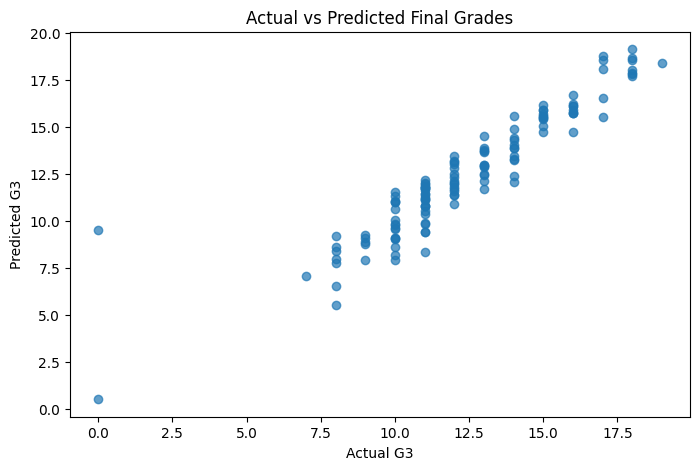

In [28]:
# Actual vs Predicted Final Grades

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_linear, alpha=0.7)

plt.title("Actual vs Predicted Final Grades")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")

plt.show()

In [29]:
# Calculate prediction errors

errors = y_test - y_pred_linear

print("Mean Error:", errors.mean())
print("Minimum Error:", errors.min())
print("Maximum Error:", errors.max())

Mean Error: -0.11048188168068292
Minimum Error: -9.503716364848176
Maximum Error: 2.668605470586085


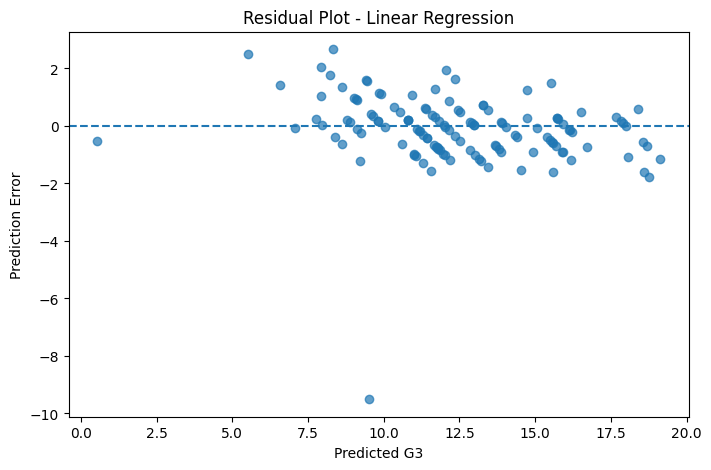

In [30]:
# Residual plot

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_linear, errors, alpha=0.7)
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted G3")
plt.ylabel("Prediction Error")

plt.show()

In [31]:
import joblib

# Save the trained Linear Regression pipeline
joblib.dump(linear_model, "student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!


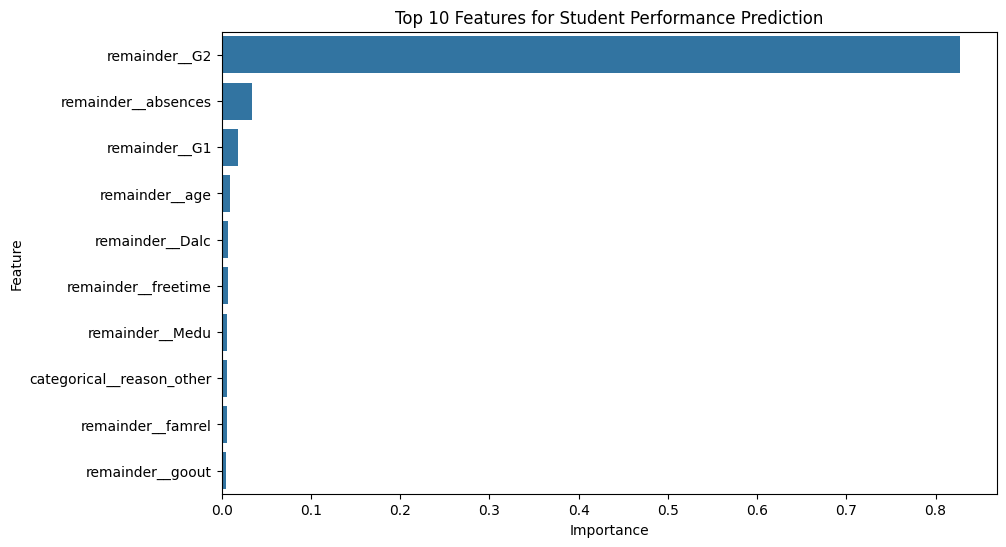

In [32]:
# Visualize Top 10 Important Features

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features for Student Performance Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [33]:
# Predict the final grade for one test student

sample_student = X_test.iloc[[0]]
actual_grade = y_test.iloc[0]

predicted_grade = linear_model.predict(sample_student)[0]

print("Actual Final Grade (G3):", actual_grade)
print("Predicted Final Grade (G3):", round(predicted_grade, 2))

Actual Final Grade (G3): 19
Predicted Final Grade (G3): 18.4


# Student Performance AI Predictor

## Machine Learning Internship Project

### Objective
Predict students' final academic performance (G3) using previous grades, study habits, attendance, and other student-related information.

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab

## 1. Dataset

The Student Performance dataset contains academic, demographic, social, and school-related information about students.

### Dataset Details
- Number of students: 649
- Number of input features: 30
- Target variables: G1, G2, G3
- Final grade (G3) is used as the prediction target.

### Data Source
UCI Machine Learning Repository – Student Performance Dataset

## 2. Data Cleaning

The dataset was checked for missing values and duplicate records.

### Missing Values
- Total missing values: 0
- No missing values were found in the dataset.

### Duplicate Records
- Total duplicate records: 0
- No duplicate records were found.

The dataset was therefore ready for further analysis and model preparation.

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the factors related to students' final performance.

### Key Analysis
- Distribution of final grades (G3)
- Study time vs final grade
- Absences vs final grade
- Previous grade (G1) vs final grade
- Previous grade (G2) vs final grade
- Previous failures vs final grade

### Key Findings
- Most final grades were concentrated around 10–14.
- Higher study time generally showed higher final-grade values.
- Higher numbers of absences showed fewer high-grade observations.
- G1 and G2 showed strong positive relationships with G3.
- Students with more previous failures generally had lower final-grade values.

## 4. Feature Preparation

The dataset was prepared for machine learning by separating the input features from the target variable.

### Input Features
The model uses:
- Previous grades (G1 and G2)
- Study time
- Absences
- Previous failures
- Student demographic and social information

### Target Variable
- G3 (Final Grade)

Categorical features were converted into numerical form using One-Hot Encoding.

The data was divided into:
- 80% training data
- 20% testing data

## 5. Model Training and Evaluation

Two regression algorithms were trained to predict the final grade (G3):

1. Linear Regression
2. Random Forest Regression

### Evaluation Metrics
- MAE (Mean Absolute Error)
- RMSE (Root Mean Squared Error)
- R² Score

These metrics were used to compare the prediction performance of both models.

## 6. Model Results

| Model | MAE | RMSE | R² Score |
|---|---:|---:|---:|
| Linear Regression | 0.7651 | 1.2149 | 0.8487 |
| Random Forest Regression | 0.7358 | 1.2323 | 0.8443 |

### Interpretation

Both models produced strong predictive performance on the test data.

- Linear Regression achieved a slightly lower RMSE and higher R² Score.
- Random Forest Regression achieved a slightly lower MAE.
- The results show a trade-off between the evaluation metrics.

## 7. Feature Importance and Key Insights

Feature importance was analyzed using the Random Forest model to understand which input variables contributed most to the predictions.

### Top Important Features
- Previous grade (G2)
- Absences
- Previous grade (G1)
- Age
- Alcohol consumption (Dalc)
- Free time
- Mother's education (Medu)
- Reason for choosing school
- Family relationship (famrel)
- Going out with friends (goout)

### Key Insight
Previous grade (G2) was the most important feature in the Random Forest model, followed by absences and previous grade (G1).

These findings indicate that previous academic performance and attendance-related information can be useful inputs for predicting final student performance.

## 8. Error Analysis

Prediction errors were analyzed to understand how closely the model's predictions matched the actual final grades.

### Error Analysis Results
- Mean Error: -0.11
- Minimum Error: -9.50
- Maximum Error: 2.67

The mean error was close to zero, indicating that the model did not show a large overall bias. However, some individual predictions had larger errors.

## 9. Sample Prediction

A sample student from the test dataset was used to compare the actual final grade with the predicted grade.

- Actual Final Grade (G3): 19
- Predicted Final Grade: 18.40

The prediction was close to the actual final grade, with a difference of 0.60 grade points.

## 10. Business Use Case

The model can be used as an early-support tool in educational institutions.

It can help identify students whose predicted performance may indicate a need for additional academic support.

### Recommendations
- Monitor students with low previous grades.
- Pay attention to students with higher absence levels.
- Provide additional academic support where needed.
- Use prediction results as a support tool, not as the only basis for decisions.

## 11. Limitations

- The dataset contains information from 649 students.
- Model performance may vary on other student populations.
- Feature importance shows model associations and does not prove causation.
- Predictions depend on the quality and availability of input data.

## 12. Conclusion

The Student Performance AI Predictor successfully used machine learning to predict students' final grades (G3).

Two regression models, Linear Regression and Random Forest Regression, were trained and evaluated using MAE, RMSE, and R² Score.

The analysis showed that previous academic performance, especially G2, and attendance-related information were important inputs for prediction.

This project demonstrates how machine learning can support educational institutions in identifying students who may benefit from additional academic support.

### Project Status
- Data loaded and cleaned
- Exploratory Data Analysis completed
- Features prepared
- Two machine learning models trained
- Models evaluated and compared
- Feature importance analyzed
- Error analysis completed
- Sample prediction completed
- Linear Regression model saved as `student_performance_model.pkl`

In [34]:
from google.colab import files

files.download("student_performance_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import joblib

joblib.dump(linear_model, "student_performance_model.pkl")

print("Model saved successfully!")

Model saved successfully!
